In [1]:
# Auto-reload modules when you edit the .py files (handy while iterating)
%load_ext autoreload
%autoreload 2

In [2]:
from data_pipeline import build_dataset, print_reports

returns, panel, reports = build_dataset()
print_reports(reports)


asset         obs        start          end  maxgap  extreme  ann.vol
S&P 500      2764   2015-01-05   2025-12-30       4       11   17.96%
WTI Crude    4032   2010-01-05   2026-02-02       5       14   46.63%
Prologis     3773   2009-01-05   2023-12-29       5       22   35.72%


In [3]:
from gjr_garch import fit_asset, print_bic_table, print_params, summary_table

names = {"SPX": "S&P 500", "WTI": "WTI Crude", "PLD": "Prologis"}
fits = {k: fit_asset(k, names[k], returns[k]) for k in ["SPX", "WTI", "PLD"]}

for f in fits.values():
    print_bic_table(f)
    print_params(f)


--- S&P 500: model selection (BIC) ---
  GJR-GARCH(1,1,1)-t         loglik=   -3424.7 BIC=   6897.0  dBIC=   0.0  <- selected
  GARCH(1,1)-t               loglik=   -3469.5 BIC=   6978.6  dBIC=  81.6
  GJR-GARCH(1,1,1)-Normal    loglik=   -3530.9 BIC=   7101.4  dBIC= 204.4
  GARCH(1,1)-Normal          loglik=   -3570.8 BIC=   7173.3  dBIC= 276.3
--- S&P 500: GJR-GARCH(1,1,1)-t ---
  omega=0.0261  alpha=0.0047  gamma=0.2757  beta=0.8366  nu=5.6597
  persistence(alpha+beta+gamma/2) = 0.9791  (stationary)
  leverage gamma p-value = 0.0000 (significant)
  Ljung-Box(L=10): level p=0.622 PASS, squared p=0.606 PASS

--- WTI Crude: model selection (BIC) ---
  GJR-GARCH(1,1,1)-t         loglik=   -8548.4 BIC=  17146.5  dBIC=   0.0  <- selected
  GARCH(1,1)-t               loglik=   -8558.2 BIC=  17157.8  dBIC=  11.3
  GJR-GARCH(1,1,1)-Normal    loglik=   -8678.4 BIC=  17398.3  dBIC= 251.8
  GARCH(1,1)-Normal          loglik=   -8697.8 BIC=  17428.8  dBIC= 282.3
--- WTI Crude: GJR-GARCH(1,1,1)-

In [4]:
summary_table(fits)   # returns a DataFrame -- renders as a nice table in Jupyter

,model,omega,alpha,gamma,beta,nu,persistence
asset,,,,,,,
S&P 500,"GJR-GARCH(1,1,1)-t",0.0261,0.0047,0.2757,0.8366,5.6597,0.9791
WTI Crude,"GJR-GARCH(1,1,1)-t",0.1202,0.0564,0.0749,0.8822,6.3618,0.9760
Prologis,"GJR-GARCH(1,1,1)-t",0.0388,0.0375,0.0631,0.9155,7.2249,0.9845


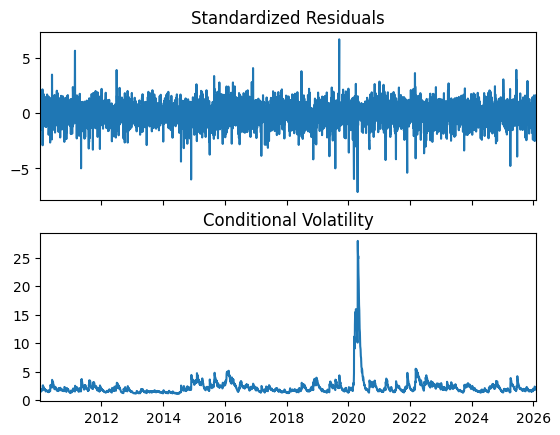

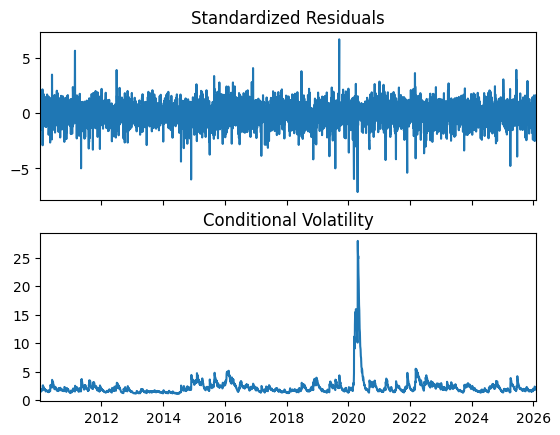

In [5]:
fits["SPX"].result.summary()      # full arch fit output: t-stats, std errors
fits["SPX"].candidates            # the BIC ranking as a DataFrame
fits["WTI"].result.plot()         # conditional volatility plot

In [6]:
from var_backtest import backtest_report

bt_results = {}
for key in ["SPX", "WTI", "PLD"]:
    bt_results[key] = backtest_report(
        returns[key], window=504, alpha=0.05, refit_every=5, label=names[key]
    )


=== VaR backtest: S&P 500 (95% 1-day VaR, dist=skewt) ===
Test days            : 2260
Violations           : 119
Observed rate        : 0.0527  (expected 0.05)
Kupiec POF  LR=0.330  p=0.566  -> PASS
Independence LR=0.494  p=0.482  -> PASS
Cond. coverage LR=0.824  p=0.662  -> PASS

=== VaR backtest: WTI Crude (95% 1-day VaR, dist=skewt) ===
Test days            : 3528
Violations           : 181
Observed rate        : 0.0513  (expected 0.05)
Kupiec POF  LR=0.125  p=0.723  -> PASS
Independence LR=0.846  p=0.358  -> PASS
Cond. coverage LR=0.972  p=0.615  -> PASS

=== VaR backtest: Prologis (95% 1-day VaR, dist=skewt) ===
Test days            : 3269
Violations           : 178
Observed rate        : 0.0545  (expected 0.05)
Kupiec POF  LR=1.327  p=0.249  -> PASS
Independence LR=8.035  p=0.005  -> FAIL
Cond. coverage LR=9.362  p=0.009  -> FAIL


In [ ]:
import pandas as pd
from var_backtest import compare_distributions

names = {"SPX": "S&P 500", "WTI": "WTI Crude", "PLD": "Prologis"}
comparison = pd.concat([
    compare_distributions(returns[k], window=504, alpha=0.05,
                          refit_every=5, label=names[k])
    for k in ["SPX", "WTI", "PLD"]
], ignore_index=True)

comparison

In [ ]:
from var_backtest import rolling_var_forecast
bt_pld = rolling_var_forecast(returns["PLD"], dist="skewt")
viol = bt_pld[bt_pld["violation"] == 1]
print(f"Prologis skew-t violations: {len(viol)}")
print(viol.index.year.value_counts().sort_index())

In [ ]:
from var_backtest import rolling_var_forecast, christoffersen
bt_pld = rolling_var_forecast(returns["PLD"], dist="skewt")
c = christoffersen(bt_pld["violation"])
t = c["transitions"]
uncond = bt_pld["violation"].mean()
cond = t["n11"] / (t["n11"] + t["n10"])   # P(violation | violation yesterday)
print(f"P(violation)                 : {uncond:.3f}")
print(f"P(violation | breach yesterday): {cond:.3f}")
print(f"transitions: {t}")

In [ ]:
import importlib, ms_garch; importlib.reload(ms_garch)
from ms_garch import fit_msgarch, print_msgarch
import pandas as pd

single_bic = {"SPX": 6897.0, "WTI": 17146.5, "PLD": 14154.0}  # from your earlier fits
ms_fits = {}
for k in ["SPX", "WTI", "PLD"]:
    res = fit_msgarch(returns[k], n_starts=8, seed=5)
    ms_fits[k] = res
    print_msgarch(res, names[k])
    verdict = "MS WINS" if res.bic < single_bic[k] else "single wins"
    print(f"  single-regime BIC {single_bic[k]} vs MS {res.bic:.1f}  -> {verdict}")
    cp = pd.Series(res.filtered[:,1], index=returns[k].index)
    print("  crisis-regime prob by year (%):")
    print((cp.groupby(cp.index.year).mean()*100).round(0).astype(int).to_string())
    print()

In [ ]:
import importlib, ms_garch, ms_var_backtest
importlib.reload(ms_garch); importlib.reload(ms_var_backtest)
from ms_var_backtest import msgarch_backtest_report

for k in ["SPX", "WTI", "PLD"]:
    msgarch_backtest_report(returns[k], window=504, alpha=0.05,
                            refit_every=42, label=names[k])

In [ ]:
import importlib, egarch_horserace; importlib.reload(egarch_horserace)
from egarch_horserace import horse_race, horse_race_table

results = []
for k in ["SPX", "WTI", "PLD"]:
    results.append(horse_race(returns[k], label=names[k], refit_every=21))
horse_race_table(results)